## The Game-of-Thrones graph

![](img/GoT.jpg)

#### Required installations

tbd

#### Imports

In [1]:
import networkx as nx
import pandas as pd
pd.options.display.max_rows = 400
import matplotlib.pyplot as plt

---

### The *Game of Thrones* dataset

#### *GoT* Network

The network data that we're going to use in this lesson is taken from Andrew Beveridge and Jie Shan's paper, ["Network of Thrones."](https://www.maa.org/sites/default/files/pdf/Mathhorizons/NetworkofThrones%20%281%29.pdf)

These researchers calculated how many times each Game of Thrones character appeared within 15 words of another character in *A Storm of Swords*, the third book in the series.

| Network Element      | GOT |         
| :-------------: |:-------------:| 
| Node    | GOT character | 
| Edge     | Mutually mentioned within 15 words      | 
| Float | Decimal Numbers      |  
| Boolean | True/False     |   


For example, the following sentence counts as an "edge" or connection between Jon Snow and Sam Tarly:

> "It was the bastard **Jon Snow** who had taken that from him, him and his fat friend **Sam Tarly**."

> "Lucky it might be, and red it certainly was, but **Ygritte**’s hair was such a tangle that **Jon** was tempted to ask her if she only brushed it at the changing of the seasons."

> "**Arya** gave **Gendry** a sideways look. *He said it with me, like **Jon** used to do, back in Winterfell.* She missed **Jon Snow** the most of all her brothers.""

#### Get data

In [6]:
got_df = pd.read_csv('./datasets/data/got-edges.csv')
got_df.info()
got_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Source  352 non-null    object
 1   Target  352 non-null    object
 2   Weight  352 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.4+ KB


,Source,Target,Weight
0,Aemon,Grenn,5
1,Aemon,Samwell,31
2,Aerys,Jaime,18
3,Aerys,Robert,6
4,Aerys,Tyrion,5


---

### Create a graph from a Pandas dataframe

In [7]:
G = nx.from_pandas_edgelist(got_df, 'Source', 'Target', 'Weight')
print(G)
# show first 5 edges with attributes
print(list(G.edges(data=True))[:5]) 

Graph with 107 nodes and 352 edges
[('Aemon', 'Grenn', {'Weight': 5}), ('Aemon', 'Samwell', {'Weight': 31}), ('Aemon', 'Jon', {'Weight': 30}), ('Aemon', 'Robert', {'Weight': 4}), ('Aemon', 'Stannis', {'Weight': 4})]


#### Drawing the first GoT graph

plt.figure(figsize=(1,1)) would create an inch-by-inch image, which would be 80-by-80 pixels if you stick with the default dpi value.

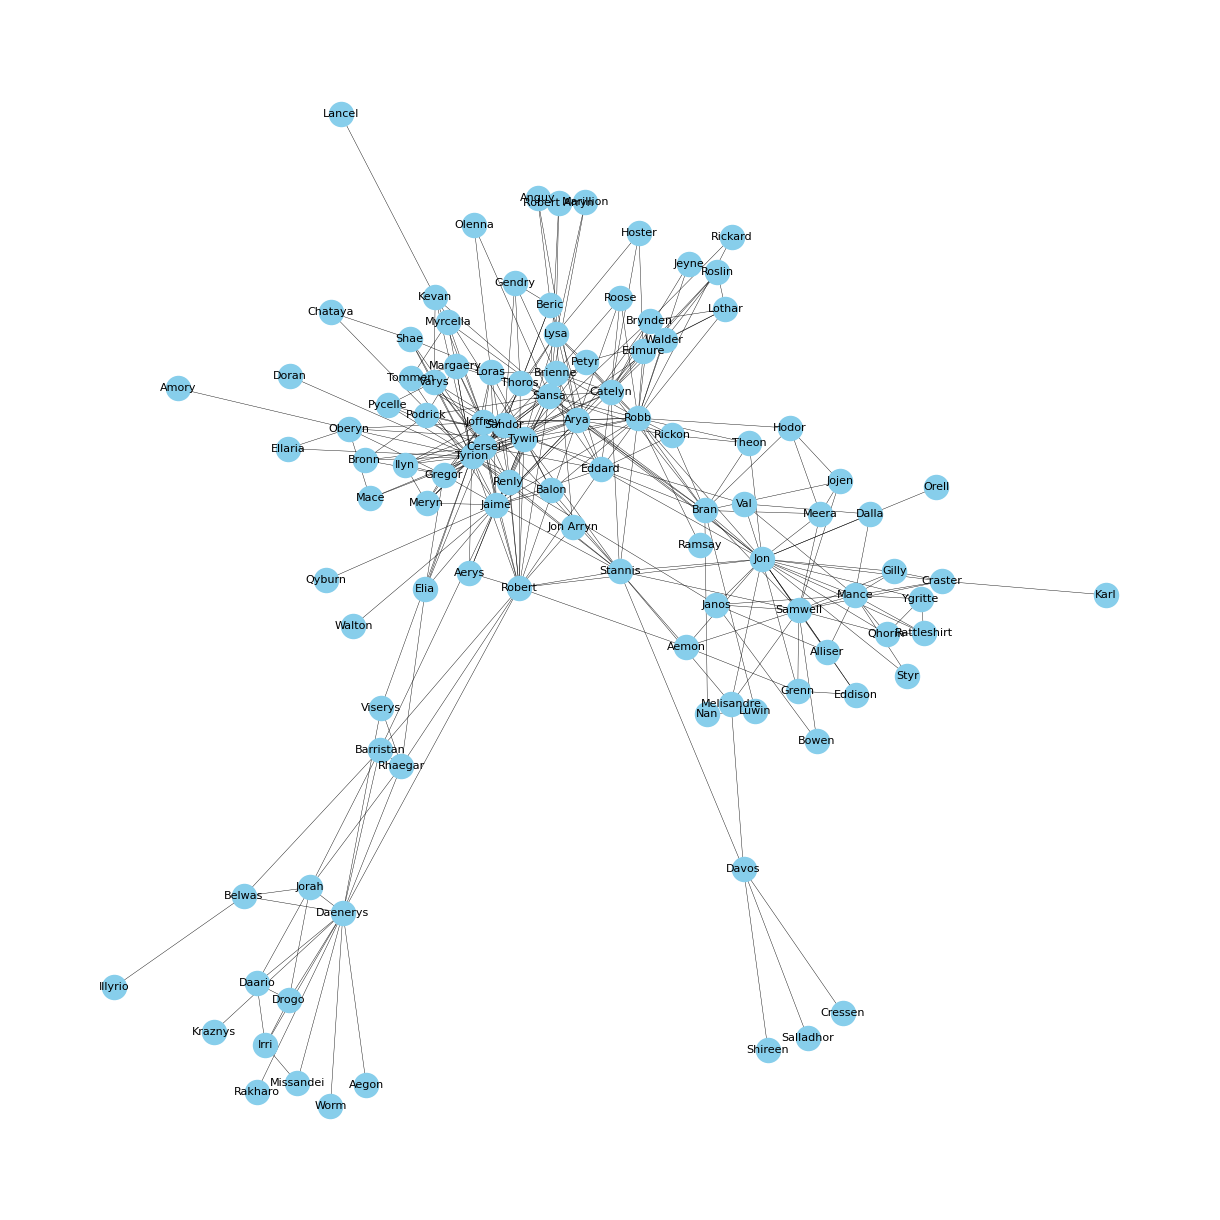

In [8]:
plt.figure(figsize=(12,12))
nx.draw(G, with_labels=True, node_color='skyblue', width=.3, font_size=8)
plt.show()

#### Calculate node degree

Make the degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [10]:
degrees = dict(nx.degree(G))
nx.set_node_attributes(G, name='degree', values=degrees)
for n, attr in list(G.nodes(data=True))[0:5]:
    print(f"{n} {attr}")

Aemon {'degree': 5}
Grenn {'degree': 4}
Samwell {'degree': 15}
Aerys {'degree': 4}
Jaime {'degree': 24}


Additionally, we can see the attributes of individual nodes:

In [ ]:
G.nodes["Grenn"]

Make a Pandas dataframe from the degree data `G.nodes(data='degree')`, then sort from highest to lowest

In [11]:
degree_df = pd.DataFrame(G.nodes(data='degree'), columns=['node', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)
degree_df[:10]

,node,degree
6,Tyrion,36
21,Jon,26
50,Sansa,26
48,Robb,25
4,Jaime,24
7,Tywin,22
17,Cersei,20
12,Arya,19
42,Catelyn,18
20,Joffrey,18


Plot the nodes with the highest degree values

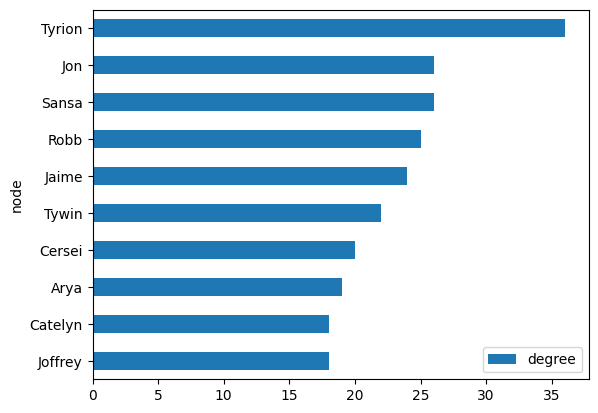

In [12]:
num_nodes_to_inspect = 10
degree_df[:num_nodes_to_inspect].plot(x='node', y='degree', kind='barh').invert_yaxis()

#### Calculate Weighted Degree

Who has the most number of connections in the network (if you factor in edge weight)?

In [13]:
nx.degree(G, weight='Weight')

DegreeView({'Aemon': 74, 'Grenn': 81, 'Samwell': 282, 'Aerys': 37, 'Jaime': 372, 'Robert': 128, 'Tyrion': 551, 'Tywin': 204, 'Alliser': 29, 'Mance': 160, 'Amory': 5, 'Oberyn': 76, 'Arya': 269, 'Anguy': 15, 'Beric': 75, 'Bran': 344, 'Brynden': 55, 'Cersei': 226, 'Gendry': 59, 'Gregor': 117, 'Joffrey': 255, 'Jon': 442, 'Rickon': 81, 'Roose': 17, 'Sandor': 137, 'Thoros': 60, 'Balon': 29, 'Loras': 76, 'Belwas': 67, 'Barristan': 63, 'Illyrio': 10, 'Hodor': 177, 'Jojen': 125, 'Luwin': 8, 'Meera': 139, 'Nan': 18, 'Theon': 38, 'Brienne': 122, 'Bronn': 59, 'Podrick': 64, 'Lothar': 34, 'Walder': 87, 'Catelyn': 184, 'Edmure': 98, 'Hoster': 24, 'Jeyne': 28, 'Lysa': 108, 'Petyr': 89, 'Robb': 342, 'Roslin': 32, 'Sansa': 383, 'Stannis': 146, 'Elia': 29, 'Ilyn': 32, 'Meryn': 47, 'Pycelle': 24, 'Shae': 45, 'Varys': 49, 'Craster': 75, 'Karl': 6, 'Daario': 30, 'Drogo': 35, 'Irri': 33, 'Daenerys': 232, 'Aegon': 8, 'Jorah': 89, 'Kraznys': 10, 'Missandei': 30, 'Rakharo': 7, 'Rhaegar': 42, 'Viserys': 19, 'Wo

Make the weighted degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [14]:
weighted_degrees = dict(nx.degree(G, weight='Weight'))
nx.set_node_attributes(G, name='weighted_degree', values=weighted_degrees)

Make a Pandas dataframe from the degree data `G.nodes(data='weighted_degree')`, then sort from highest to lowest

In [15]:
weighted_degree_df = pd.DataFrame(G.nodes(data='weighted_degree'), columns=['node', 'weighted_degree'])
weighted_degree_df = weighted_degree_df.sort_values(by='weighted_degree', ascending=False)
weighted_degree_df[:10]

,node,weighted_degree
6,Tyrion,551
21,Jon,442
50,Sansa,383
4,Jaime,372
15,Bran,344
48,Robb,342
2,Samwell,282
12,Arya,269
20,Joffrey,255
63,Daenerys,232


Plot the nodes with the highest weighted degree values

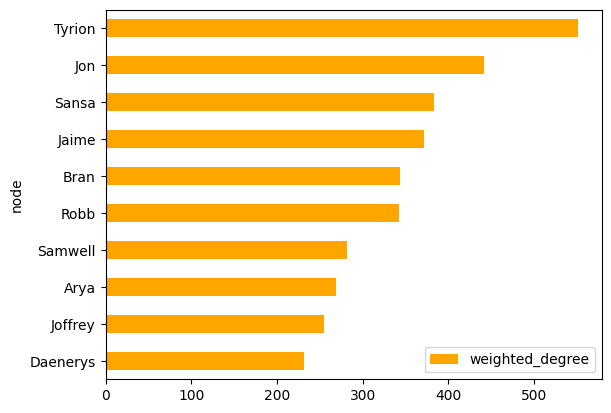

In [16]:
num_nodes_to_inspect = 10
weighted_degree_df[:num_nodes_to_inspect].plot(x='node', y='weighted_degree', color='orange', kind='barh').invert_yaxis()

#### Calculate Betweenness Centrality Scores

In graph theory, betweenness centrality is a measure of centrality in a graph based on shortest paths. 
In short: How many shortest paths pass a node?
More precise: What is the fraction of a graph's shortest paths that pass a certain node?

In [17]:
betweenness_centrality = nx.betweenness_centrality(G)

Add `betweenness_centrality` (which is already a dictionary) as a node attribute with `networkx.set_node_attributes()`

In [18]:
nx.set_node_attributes(G, name='betweenness', values=nx.betweenness_centrality(G))

Make a Pandas dataframe from the betweenness data `G.nodes(data='betweenness')`, then sort from highest to lowest

In [19]:
betweenness_df = pd.DataFrame(G.nodes(data='betweenness'), columns=['node', 'betweenness'])
betweenness_df = betweenness_df.sort_values(by='betweenness', ascending=False)
betweenness_df[:10]

,node,betweenness
21,Jon,0.229965
5,Robert,0.209452
6,Tyrion,0.197913
63,Daenerys,0.157203
48,Robb,0.126964
50,Sansa,0.126720
51,Stannis,0.102700
4,Jaime,0.099943
12,Arya,0.079607
7,Tywin,0.065538


Plot the nodes with the highest betweenness centrality scores

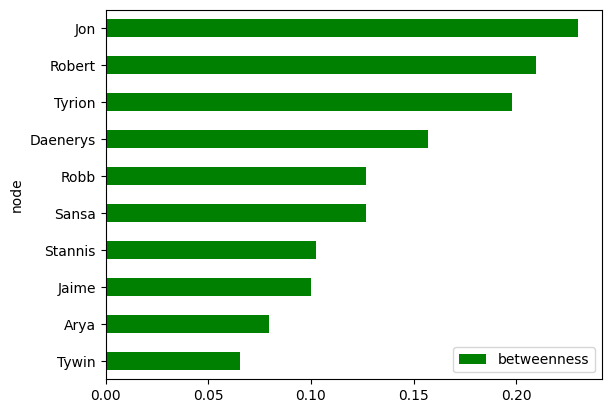

In [20]:
num_nodes_to_inspect = 10
betweenness_df[:num_nodes_to_inspect].plot(x='node', y='betweenness', color='green', kind='barh').invert_yaxis()

---

### Communities

Who forms distinct communities within this network?

In [21]:
from networkx.algorithms import community as com

Calculate communities with `community.greedy_modularity_communities()`

In [ ]:
communities = com.greedy_modularity_communities(G)
communities

Make a `dict`ionary by looping through the communities and, for each member of the community, adding their community number

In [25]:
#Create empty dictionary
modularity_class = {}
#Loop through each community in the network
for community_number, community in enumerate(communities):
    #For each member of the community, add their community number
    for name in community:
        modularity_class[name] = community_number
print(modularity_class)

{'Podrick': 0, 'Myrcella': 0, 'Oberyn': 0, 'Loras': 0, 'Chataya': 0, 'Mace': 0, 'Ilyn': 0, 'Tyrion': 0, 'Balon': 0, 'Bronn': 0, 'Margaery': 0, 'Tommen': 0, 'Gregor': 0, 'Pycelle': 0, 'Joffrey': 0, 'Elia': 0, 'Renly': 0, 'Amory': 0, 'Olenna': 0, 'Jaime': 0, 'Lancel': 0, 'Varys': 0, 'Shae': 0, 'Sandor': 0, 'Meryn': 0, 'Qyburn': 0, 'Walton': 0, 'Tywin': 0, 'Ellaria': 0, 'Aerys': 0, 'Kevan': 0, 'Doran': 0, 'Melisandre': 1, 'Jojen': 1, 'Dalla': 1, 'Ygritte': 1, 'Mance': 1, 'Jon': 1, 'Shireen': 1, 'Craster': 1, 'Samwell': 1, 'Hodor': 1, 'Val': 1, 'Styr': 1, 'Bowen': 1, 'Alliser': 1, 'Aemon': 1, 'Meera': 1, 'Qhorin': 1, 'Karl': 1, 'Stannis': 1, 'Janos': 1, 'Orell': 1, 'Davos': 1, 'Rattleshirt': 1, 'Gilly': 1, 'Eddison': 1, 'Cressen': 1, 'Grenn': 1, 'Salladhor': 1, 'Petyr': 2, 'Luwin': 2, 'Rickon': 2, 'Edmure': 2, 'Brienne': 2, 'Cersei': 2, 'Eddard': 2, 'Robert Arryn': 2, 'Roose': 2, 'Robb': 2, 'Sansa': 2, 'Nan': 2, 'Catelyn': 2, 'Rickard': 2, 'Brynden': 2, 'Arya': 2, 'Hoster': 2, 'Bran': 2, '

Add modularity class to the network as an attribute

In [26]:
nx.set_node_attributes(G, modularity_class, 'modularity_class')
# show first 5 nodes with their attributes
print(list(G.nodes(data=True))[:5])  

[('Aemon', {'degree': 5, 'weighted_degree': 74, 'betweenness': 0.004622508177397137, 'modularity_class': 1}), ('Grenn', {'degree': 4, 'weighted_degree': 81, 'betweenness': 5.989817310572027e-05, 'modularity_class': 1}), ('Samwell', {'degree': 15, 'weighted_degree': 282, 'betweenness': 0.03227262859511145, 'modularity_class': 1}), ('Aerys', {'degree': 4, 'weighted_degree': 37, 'betweenness': 0.0, 'modularity_class': 0}), ('Jaime', {'degree': 24, 'weighted_degree': 372, 'betweenness': 0.09994344156136246, 'modularity_class': 0})]


Make a Pandas dataframe from modularity class network data `G.nodes(data='modularity_class')`

In [27]:
communities_df = pd.DataFrame(G.nodes(data='modularity_class'), columns=['node', 'modularity_class'])
communities_df = communities_df.sort_values(by='modularity_class', ascending=False)
communities_df[:10]

,node,modularity_class
18,Gendry,4
13,Anguy,4
14,Beric,4
25,Thoros,4
28,Belwas,3
30,Illyrio,3
29,Barristan,3
5,Robert,3
64,Aegon,3
66,Kraznys,3


Inspect each community in the network

In [28]:
communities_df[communities_df['modularity_class'] == 4][:10]

,node,modularity_class
18,Gendry,4
13,Anguy,4
14,Beric,4
25,Thoros,4


In [29]:
communities_df[communities_df['modularity_class'] == 3][:10]

,node,modularity_class
28,Belwas,3
30,Illyrio,3
29,Barristan,3
5,Robert,3
64,Aegon,3
66,Kraznys,3
67,Missandei,3
71,Worm,3
68,Rakharo,3
69,Rhaegar,3


In [30]:
communities_df[communities_df['modularity_class'] == 2][:10]

,node,modularity_class
36,Theon,2
41,Walder,2
42,Catelyn,2
48,Robb,2
49,Roslin,2
50,Sansa,2
44,Hoster,2
45,Jeyne,2
43,Edmure,2
35,Nan,2


In [31]:
communities_df[communities_df['modularity_class'] == 1][:10]

,node,modularity_class
81,Janos,1
88,Orell,1
93,Ygritte,1
82,Bowen,1
104,Shireen,1
91,Styr,1
92,Val,1
86,Dalla,1
89,Qhorin,1
32,Jojen,1


In [32]:
communities_df[communities_df['modularity_class'] == 0][:10]

,node,modularity_class
39,Podrick,0
38,Bronn,0
27,Loras,0
11,Oberyn,0
19,Gregor,0
20,Joffrey,0
24,Sandor,0
26,Balon,0
6,Tyrion,0
4,Jaime,0


---

### All Network Metrics

Create a Pandas dataframe of all network attributes by creating a `dict`ionary of `G.nodes(data=True)` and then [transposing it](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.T.html) (flipping the columns and rows) with `.T`

In [33]:
nodes_df = pd.DataFrame(dict(G.nodes(data=True))).T
nodes_df[:10]

,degree,weighted_degree,betweenness,modularity_class
Aemon,5.0,74.0,0.004623,1.0
Grenn,4.0,81.0,0.000060,1.0
Samwell,15.0,282.0,0.032273,1.0
Aerys,4.0,37.0,0.000000,0.0
Jaime,24.0,372.0,0.099943,0.0
Robert,18.0,128.0,0.209452,3.0
Tyrion,36.0,551.0,0.197913,0.0
Tywin,22.0,204.0,0.065538,0.0
Alliser,3.0,29.0,0.000000,1.0
Mance,12.0,160.0,0.007276,1.0


In [34]:
nodes_df.sort_values(by='betweenness', ascending=False)[:10]

,degree,weighted_degree,betweenness,modularity_class
Jon,26.0,442.0,0.229965,1.0
Robert,18.0,128.0,0.209452,3.0
Tyrion,36.0,551.0,0.197913,0.0
Daenerys,14.0,232.0,0.157203,3.0
Robb,25.0,342.0,0.126964,2.0
Sansa,26.0,383.0,0.126720,2.0
Stannis,14.0,146.0,0.102700,1.0
Jaime,24.0,372.0,0.099943,0.0
Arya,19.0,269.0,0.079607,2.0
Tywin,22.0,204.0,0.065538,0.0
